In [ ]:
from sklearn.datasets import fetch_covtype
from dataloading import prepare_data
from utils import train_iteratively, uncertainty
import plots
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# Load dataset

In [2]:
cov_type = fetch_covtype()
np.unique_counts(cov_type["target"]).counts

array([211840, 283301,  35754,   2747,   9493,  17367,  20510])

# Plot class imbalance  

In [13]:
data,explained_var = prepare_data(
    cov_type,
    n_init=100,
    n_points=20000,   # optional (set None to use full dataset)
    seed=42,
    even_distribution=False
)

TypeError: plot_class_distribution() got an unexpected keyword argument 'show'

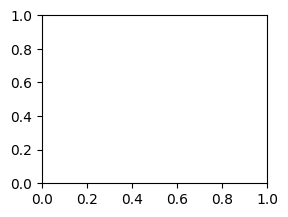

In [15]:
plt.subplot(2, 2, 1)
plots.plot_class_distribution(cov_type["target"], "Original", show = False)

plt.subplot(2, 2, 2)
plots.plot_class_distribution(data['train']['y'], "Train", show = False)

plt.subplot(2, 2, 3)
plots.plot_class_distribution(data['pool']['y'], "Pool", show = False)

plt.subplot(2, 2, 4)
plots.plot_class_distribution(data['Test']['y'], "Test", show = False)

plt.suptitle("Class distributions")
plt.tight_layout()
plt.show()

# Train the model

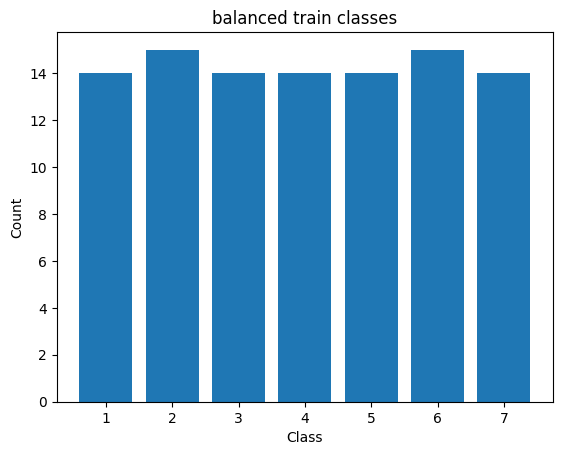

In [ ]:
data,explained_var = prepare_data(
    cov_type,
    n_init=100,
    n_points=20000,   # optional (set None to use full dataset)
    seed=42,
    even_distribution=True
)

plots.plot_class_distribution(data["train"]["y"], "Balanced train classes")

In [ ]:


model = LogisticRegression(solver='lbfgs', max_iter=400)

test_acc = train_iteratively(data, model, "random", 20, 5)
test_acc